In [23]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg as la
import model as m

NOTE: $D$ apparently is not a 'controllable' variable. So including it in our state equation + cost functional is bad. We changed the model so if you specify `no_dead=True` in the constructor then it will not output $D$ which is fine because we can compute it by subtracting the sum of the other variables from the total initial population. - Jeremy + Henry.

In [24]:
def solve_linearized_infinite(A, B, y0, t0, tf):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''

    # solve continuous algebraic Riccati equation to get P
    P = la.solve_continuous_are(A, B, Q, R)

    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    # solve the optimal state evolution, and plot the position & velocity
    sol = solve_ivp(chytrid_evolve, [0, tf], y0, dense_output=True)
    t = np.linspace(t0, tf, 10)

    # S, I, T1, D = sol.sol(t)
    S = sol.sol(t)[0]
    I = sol.sol(t)[1]
    T1 = sol.sol(t)[2]

    u = - B.T @ P @ sol.sol(t)  # control

    return np.array([S[0], I[0], T1[0]]), u[:, 0]


In [25]:
def solve_linearized_finite(A, B, y0, t0, tf):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''
    t_steps = 10
    t_space = np.linspace(t0, tf, t_steps)

    def P_evolve(t, p): # riccatti ode
        P = p.reshape(A.shape[0], A.shape[0])
        return (-P @ A - A.T @ P - Q + P @ B @ B.T @ P).flatten()
    
    pf = np.zeros(A.shape[0]**2) # P(t_f) = M = 0
    sol_P = solve_ivp(P_evolve, [tf, t0], pf, dense_output=True, t_eval=t_space[::-1]) # TODO change to t0 or 0
    p = sol_P.y
    P = p.reshape(sol_P.t.shape[0], A.shape[0], A.shape[0])[::-1]

    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        P = sol_P.sol(t).reshape(A.shape[0], A.shape[0])
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    # solve the optimal state evolution, and plot the position & velocity
    sol_x = solve_ivp(chytrid_evolve, [t0, tf], y0, dense_output=True, t_eval=t_space)   # TODO change to t0 or 0

    # S, I, T1, D = sol.sol(t)
    S = sol_x.sol(t_space)[0]
    I = sol_x.sol(t_space)[1]
    T1 = sol_x.sol(t_space)[2]

    x = np.array([S[0], I[0], T1[0]])
    u = - B.T @ P[1] @ x  # control

    return x, u

In [26]:
def iterated_lqr(Df_x, Df_u, t_space, x0, u0):
    '''
    Solve for control and state solutions at discrete steps using LQR at each step
    Args:
        Df_x: a function to linearize with respect to x, returns matrix A for LQR
        Df_u: a function to linearize with respect to x, returns matrix B for LQR
        t_space: time steps on which to evaluate our solution
        x0: initial state
        u0: initial control

    Returns:
        state_solutions: array of optimal state over time
        control_solutions: array of optimal control over time

    '''
    # store initial states in our solution
    state_solutions = [x0]
    control_solutions = [u0]
    acceptable_times = [t_space[0]]

    for i in range(len(t_space) - 1):   # iterate through each time step
        # get linearizations at this time step
        A = Df_x(0, state_solutions[-1], control_solutions[-1]) 
        B = Df_u(0, state_solutions[-1], control_solutions[-1])

        # uodate next step using LQR
        try:
            x_new, u_new = solve_linearized_infinite(A, B, state_solutions[-1], t_space[i], t_space[i+1])   # get next state using LQR
            state_solutions.append(x_new)
            control_solutions.append(u_new)
            acceptable_times.append(t_space[i])
        except:
            continue

    return np.array(state_solutions), np.array(control_solutions), acceptable_times   # optimal states and optimal controls 

In [27]:
# given by our model
Q = np.array([[0, 0, 0],
             [0, 3, 0],
             [0, 0, 0]])    # cost of frog death

R = np.eye(1)   # cost of control

# initial conditions
y0 = np.array([475, 25, 0])
u0 = np.array([0])  # spending on baths
const_u1 = 0.1

# establish t space
tf = 1000
t_steps = 5000
t_space = np.linspace(0, tf, t_steps)

# instantiate model object (to be used for linearization)
model = m.Model(seasonal=False, no_dead=True, const_u1=const_u1) # constant sauna maintenance

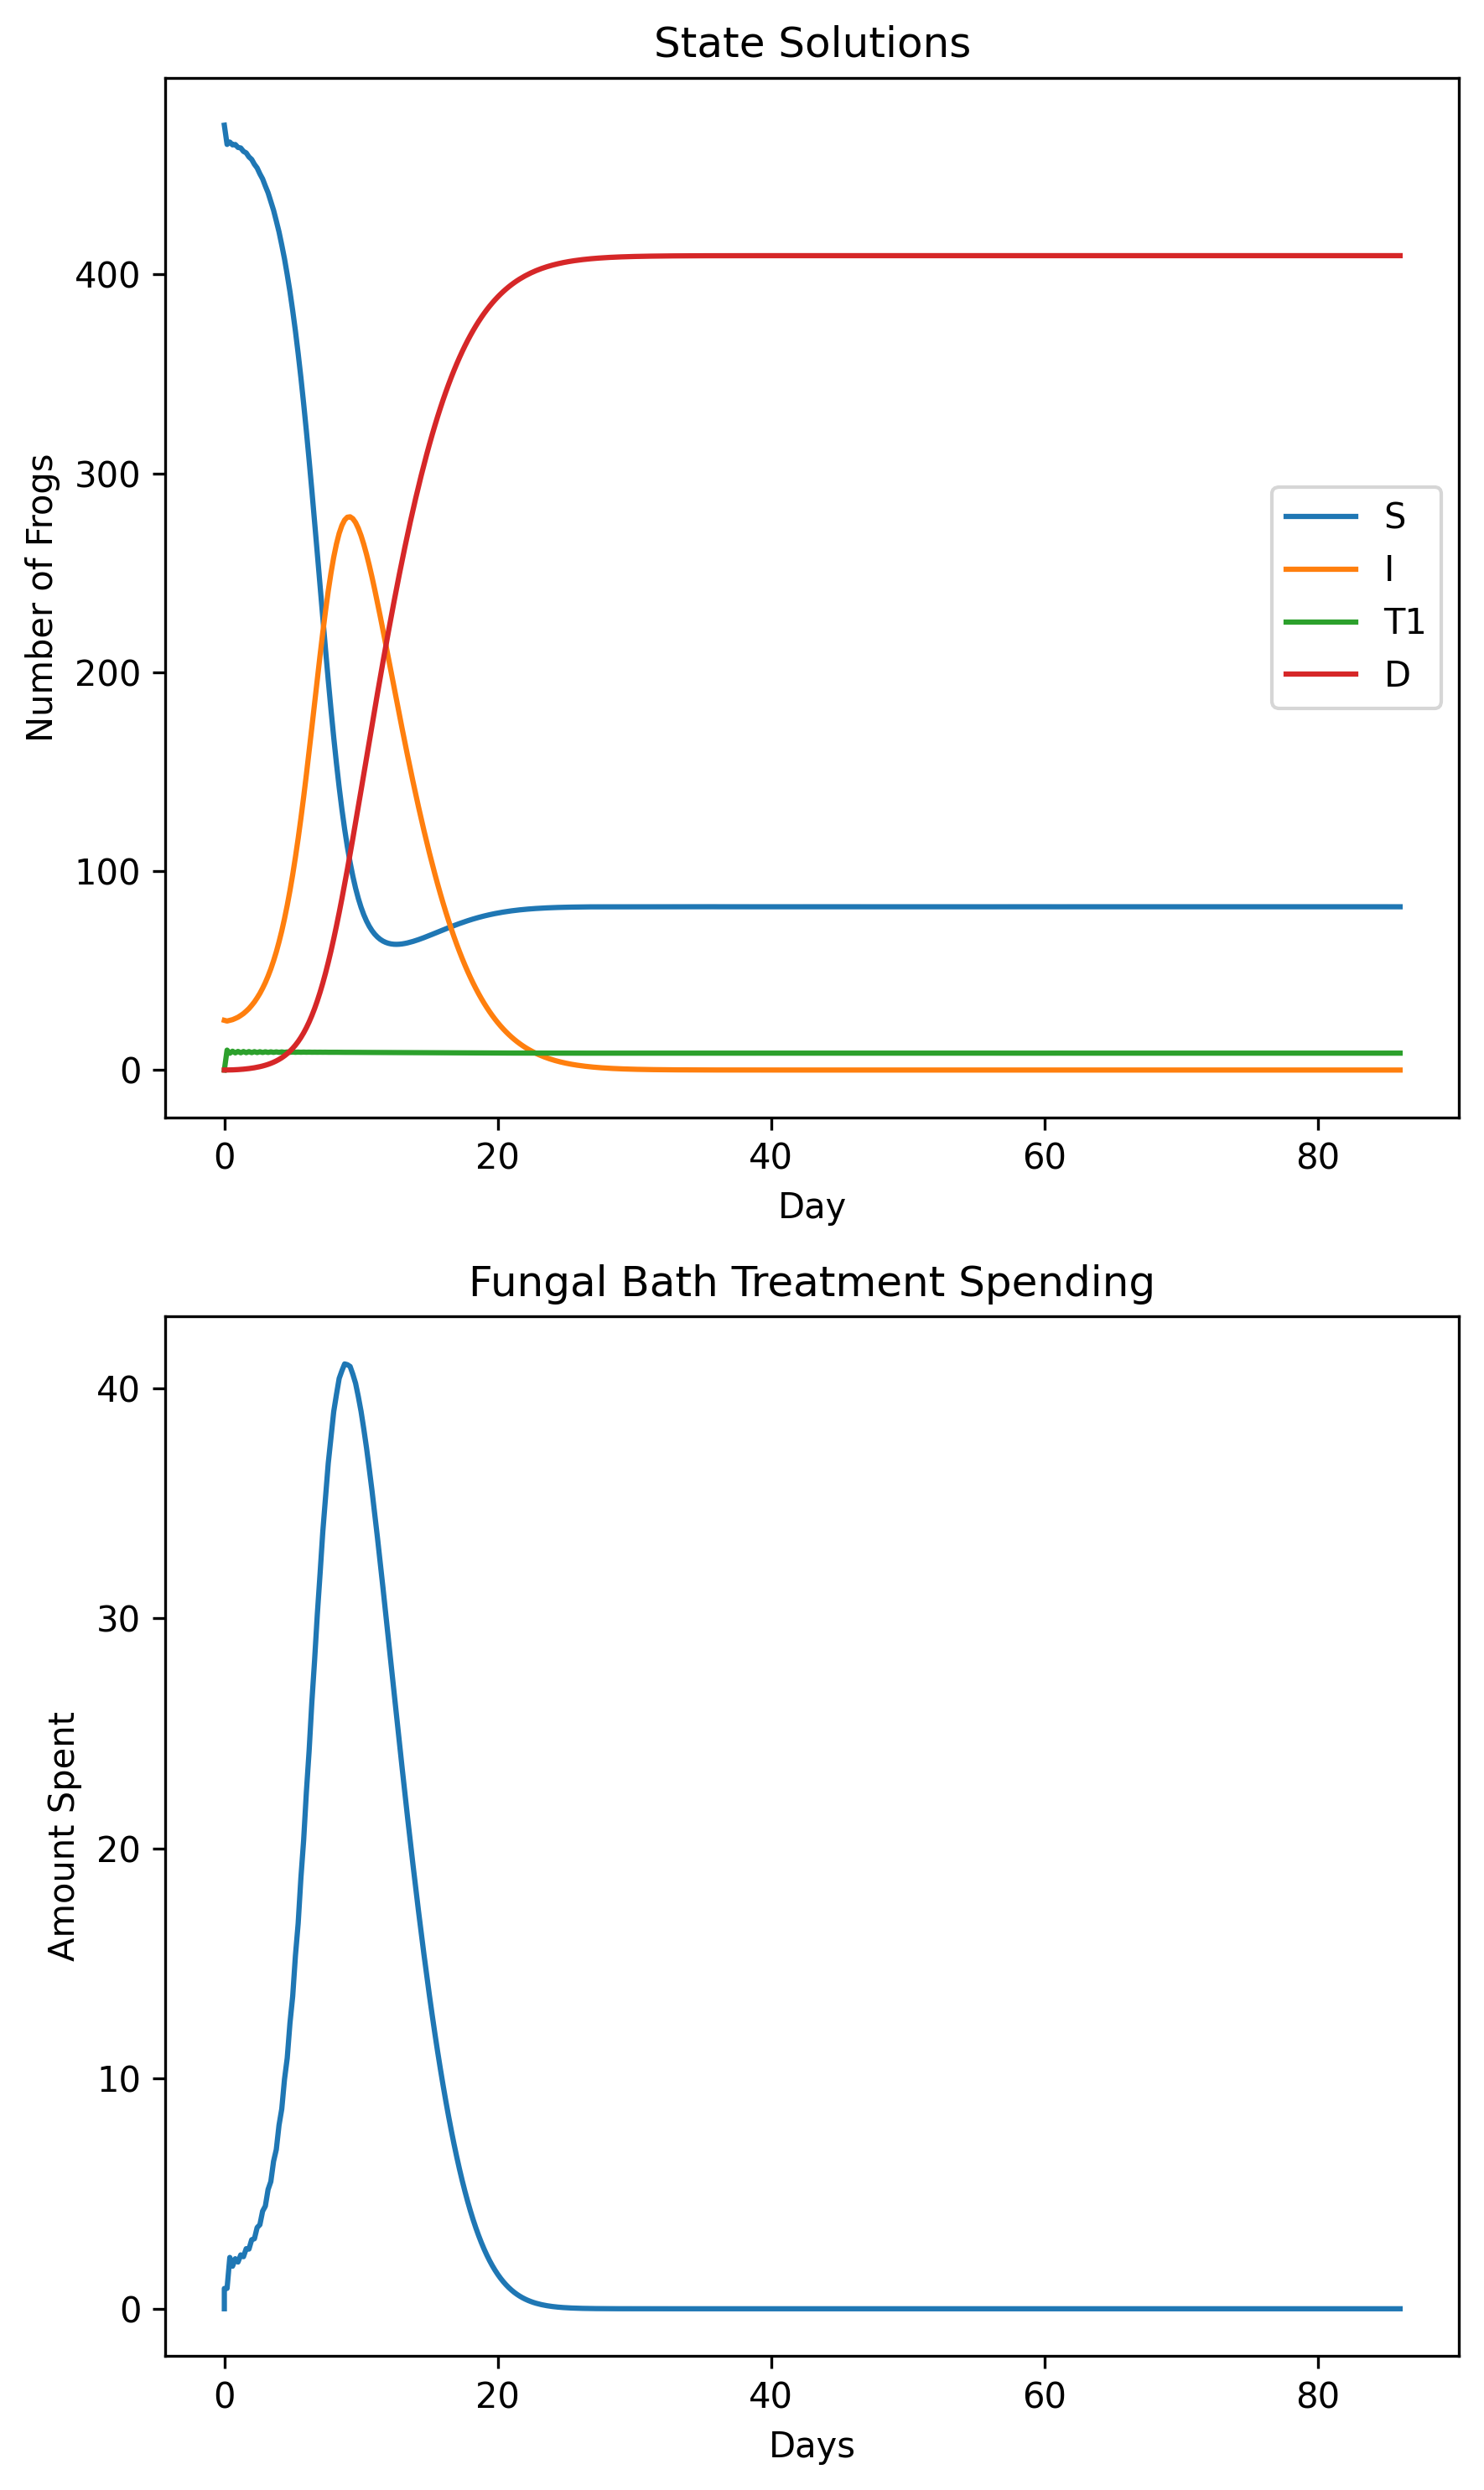

In [28]:
# get optimal solutions
x, u2, new_t = iterated_lqr(lambda t, x, u: model.f_x(t, x, u), lambda t, x, u: model.f_u(t, x, u), t_space, y0, u0)
S = x[:, 0]
I = x[:, 1]
T1 = x[:, 2]

# plot
fig, axs = plt.subplots(2, 1, figsize=(6, 10), dpi=300)
axs[0].set_title("State Solutions")
axs[0].plot(new_t, S, label="S")
axs[0].plot(new_t, I, label="I")
axs[0].plot(new_t, T1, label="T1")
axs[0].set_ylabel('Number of Frogs')
axs[0].set_xlabel('Day')
axs[0].plot(new_t, 500 - S - I - T1, label="D")  # plotting death total 500 - all other groups
axs[0].legend()

# formatting
axs[1].set_title("Fungal Bath Treatment Spending")
axs[1].plot(new_t, u2, label=rf'$u_{2}$: Antifungal Bath Spending') 
axs[1].set_xlabel('Days')
axs[1].set_ylabel('Amount Spent')

plt.tight_layout()

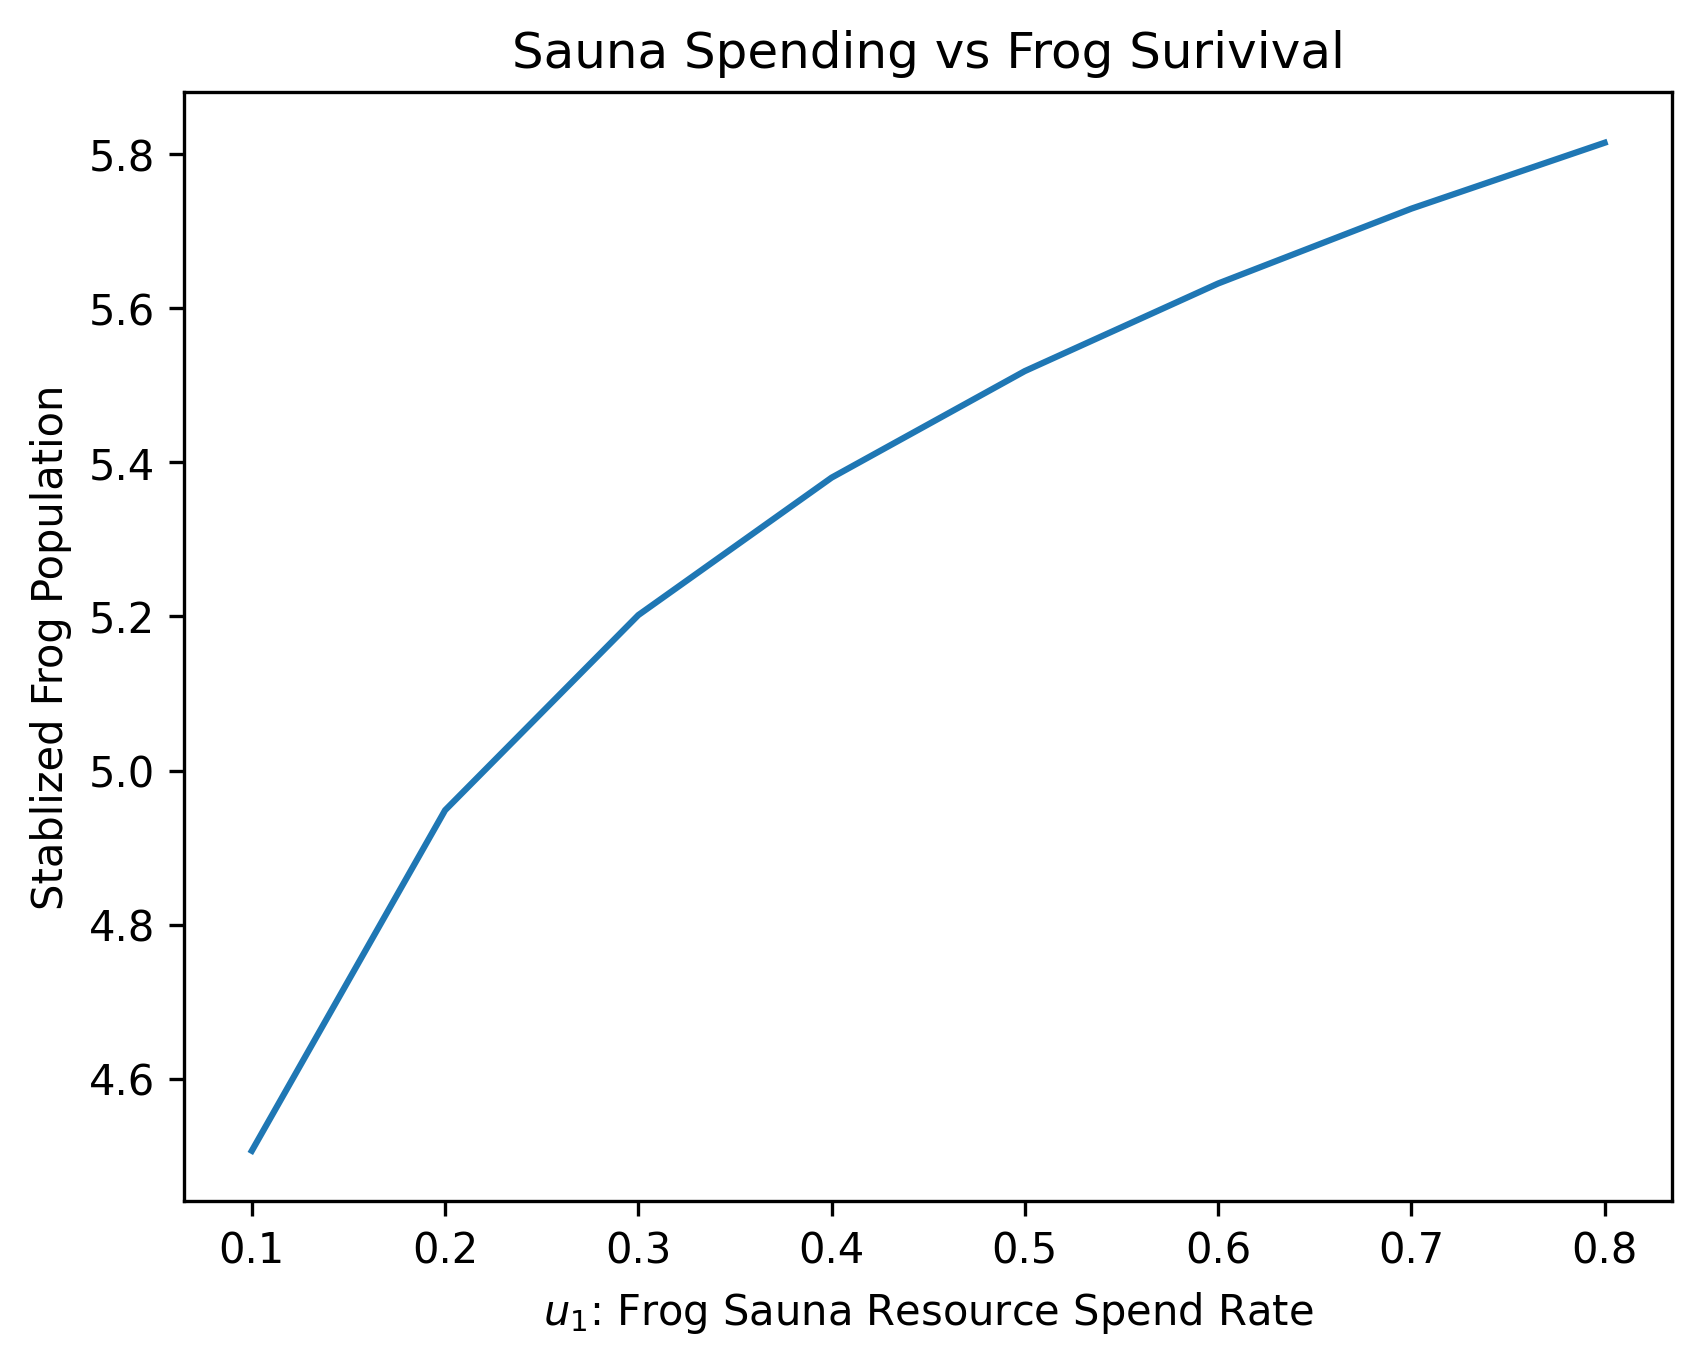

In [32]:
u1_vals = np.arange(0.1, 0.9, 0.1)
S_vals = []

for u1 in u1_vals:
    model = m.Model(seasonal=False, no_dead=True, const_u1=u1) # instantiate model object with sauna spend rate

    # solve lqr and get final frog population from the end of susceptible
    x, _, _ = iterated_lqr(lambda t, x, u: model.f_x(t, x, u), lambda t, x, u: model.f_u(t, x, u), t_space, y0, u0)
    S_equlibrium = x[:, 0][-1] + x[:, 1][-1] + x[:, 2][-1]
    S_vals.append(S_equlibrium)

# plot formatting
fig, axs = plt.subplots(1, 1, dpi=300)
plt.title('Sauna Spending vs Frog Surivival')
plt.xlabel(rf'$u_{1}$: Frog Sauna Resource Spend Rate')
plt.ylabel('Stablized Frog Population')
plt.plot(u1_vals, np.log(np.array(S_vals)))
